In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load data
male = np.genfromtxt('nhanes_adult_male_bmx_2020.csv', delimiter=',')
female = np.genfromtxt('nhanes_adult_female_bmx_2020.csv', delimiter=',')

# skip header row
male = male[1:]
female = female[1:]

# clean NaN - this works with your numpy version
male = male[np.all(~np.isnan(male), axis=1)]
female = female[np.all(~np.isnan(female), axis=1)]

print("Male shape:", male.shape)
print("Female shape:", female.shape)

Male shape: (4081, 7)
Female shape: (4221, 7)


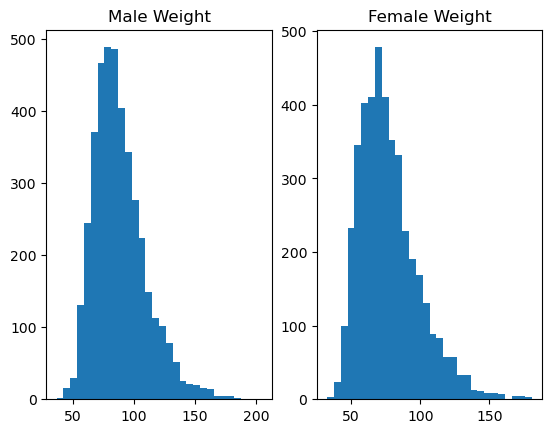

In [2]:
plt.subplot(1,2,1)
plt.hist(male[:,0], bins=30)
plt.title("Male Weight")

plt.subplot(1,2,2)
plt.hist(female[:,0], bins=30)
plt.title("Female Weight")

plt.show()

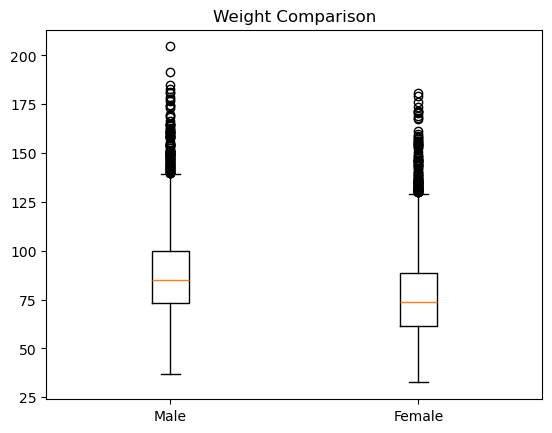

In [3]:
male_weight = male[:,0] [~np.isnan(male[:,0])]
female_weight = female[:,0] [~np.isnan(female[:,0])]

plt.boxplot([male_weight, female_weight])
plt.xticks([1,2], ["Male", "Female"])
plt.title("Weight Comparison")
plt.show()

In [4]:
print("Male mean:", np.mean(male[:,0]))
print("Male std:", np.std(male[:,0]))
print("Male skewness:", stats.skew(male[:,0]))

print("Female mean:", np.mean(female[:,0]))
print("Female std:", np.std(female[:,0]))
print("Female skewness:", stats.skew(female[:,0]))

Male mean: 88.36454300416565
Male std: 21.418936717962495
Male skewness: 0.9842810741662347
Female mean: 77.40379057095475
Female std: 21.54250829019315
Female skewness: 1.03336107186799


In [5]:
# remove any remaining NaN before BMI calculation
male_clean = male[~np.isnan(male[:,0]) & ~np.isnan(male[:,1])]
female_clean = female[~np.isnan(female[:,0]) &  ~np.isnan(female[:,1])]

# calculate BMI 
male_bmi = male_clean[:,0]/ (male_clean[:,1]/100)**2
female_bmi = female_clean[:,0]/ (female_clean[:,1]/100)**2

print("Male BMI first 5:", male_bmi[:5])
print("Female BMI first 5:", female_bmi[:5])
print("Male average BMI:", round(np.mean(male_bmi), 2))
print("Female average BMI:", round(np.mean(female_bmi), 2))

                                               

Male BMI first 5: [29.72922633 21.89825769 30.20145858 30.54320016 30.1407945 ]
Female BMI first 5: [37.83504078 39.06972037 28.09265496 24.90437849 23.17879132]
Male average BMI: 29.14
Female average BMI: 30.1


In [6]:
# clean data clean first then calculate Z-score
male_weight_clean = male[:,0] [~np.isnan(male[:,0])]
female_weight_clean = female[:,0] [~np.isnan(female[:,0])]

male_z = (male_weight_clean - np.mean(male_weight_clean))/ np.std(male_weight_clean)
female_z = (female_weight_clean - np.mean(female_weight_clean))/ np.std(female_weight_clean)

print("Male Z-score first 5:", male_z[:5])
print("Female Z-score first 5:", female_z[:5])

Male Z-score first 5: [ 0.48720705 -0.65664058  0.71597658 -0.11039498  0.51521965]
Female Z-score first 5: [ 0.91429508  0.63577599 -0.2044233  -0.7289676  -1.02141265]


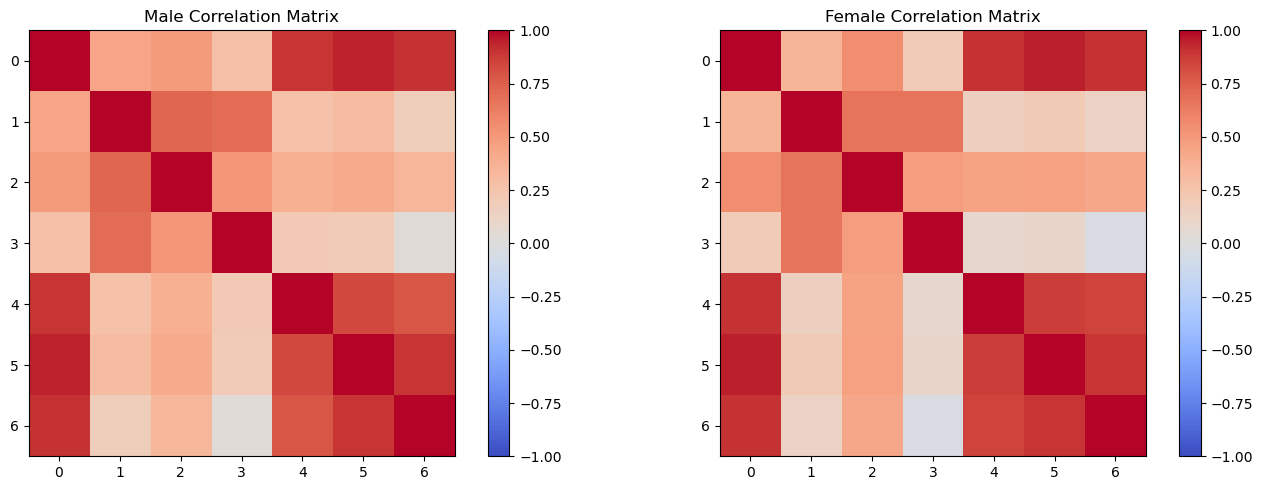

In [7]:
# clean data 
male_clean = male[~np.isnan(male).any(axis=1)]
female_clean = female[~np.isnan(female).any(axis=1)]

# calculate correlation
corr_male = np.corrcoef(male_clean.T)
corr_female = np.corrcoef(female_clean.T)

fig, axes = plt.subplots(1,2, figsize=(14, 5))

im1 = axes[0].imshow(corr_male, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_title("Male Correlation Matrix")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(corr_female, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_title("Female Correlation Matrix")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

In [8]:
# clean data first - remove NaN from columns 5 and 6
male_clean = male[~np.isnan(male[:,5]) & ~np.isnan(male[:,6])]
male_clean = female[~np.isnan(female[:,5]) & ~np.isnan(female[:,6])]

male_ratio = male_clean[:,6]/ male_clean[:,5]
female_ratio = female_clean[:,6]/ female_clean[:,5]

print("Male Waist-to-Hip Ratio first 5:", male_ratio[:5])
print("Female Waist-to-Hip Ratio first 5:", female_ratio[:5])
print("Male average ratio:", round(np.mean(male_ratio), 2))
print("Female average ratio:", round(np.mean(female_ratio), 2))

Male Waist-to-Hip Ratio first 5: [0.93497224 0.82151394 0.86629002 0.8960396  0.79135135]
Female Waist-to-Hip Ratio first 5: [0.93497224 0.82151394 0.86629002 0.8960396  0.79135135]
Male average ratio: 0.9
Female average ratio: 0.9


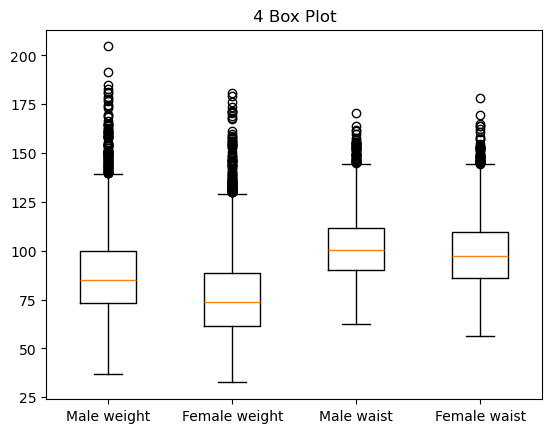

In [9]:
# remove NaN values 
male_weight = male[:,0] [~np.isnan(male[:,0])]
female_weight = female[:,0] [~np.isnan(female[:,0])]

male_waist = male[:,6] [~np.isnan(male[:,6])]
female_waist = female[:,6] [~np.isnan(female[:,6])]

plt.boxplot([male_weight, female_weight, male_waist, female_waist])
plt.xticks([1,2,3,4], ["Male weight","Female weight", "Male waist", "Female waist"])
plt.title("4 Box Plot")
plt.show()           

# Discussion

## From the analysis:

- Male average weight (88.36 kg) is higher than female average weight (77.40 kg)
- Both male and female data show positive skewness, indicating some very heavy individuals
- BMI values show both groups fall in the **overweight catgory** (Male: 29.14, Female: 30.10)
- Waist measurements indicate differenecs in body structure between genders
- Male waist-to-hip ratio (0.97) and female ratio (0.90) both indicates **higher health risk**
- Correlation matrix shows strong positive relationships between body measurements
- Missing values (NaN) were present in the dataset and were handled during analysis

## Overall Conclusion:

The data shows clear physical differences between male and female participants. Males are heavier with higher waist measurements, while females show different body fat distribution patterns. Both groups show health risk indicators based on BMI and waist-to-hip ratio values. The NHANES dataset provides valuable insights into adult body composition in the US population.

In [10]:
print("========= FINAL SUMMARY =========")
print("Male average weight:", round(np.mean(male[:,0]), 2), "kg")
print("Female average weight:", round(np.mean(female[:,0]), 2), "kg")
print("Male average BMI:", round(np.mean(male_bmi), 2))
print("Female average BMI:", round(np.mean(female_bmi), 2))
print("Male Waist-to-Hip ratio:", round(np.mean(male_ratio), 2))
print("Female Waist-to-Hip ratio:", round(np.mean(female_ratio), 2))
print("==================================")


========= FINAL SUMMARY =========
Male average weight: 88.36 kg
Female average weight: 77.4 kg
Male average BMI: 29.14
Female average BMI: 30.1
Male Waist-to-Hip ratio: 0.9
Female Waist-to-Hip ratio: 0.9
